# **EDA: ANÁLISIS EXPLORATORIO DE DATOS**

Este notebook contiene la revisión exploratoria inicial de los datasets originales, con el objetivo de evaluar su estructura, calidad y estado general antes de aplicar cualquier proceso de limpieza o transformación.

La revisión se realiza mediante una función estructurada que centraliza la validación del dataset y permite identificar posibles problemas de calidad de datos, inconsistencias y características relevantes para su posterior preparación.

In [20]:
# ============================================================================
# CONFIGURACIÓN DEL ENTORNO
# Importación de librerías para la manipulación, análisis y visualización
# de datos durante la fase exploratoria (EDA).
# ============================================================================

# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización de datos
import seaborn as sns
import matplotlib.pyplot as plt


# ============================================================================
# CONFIGURACIÓN DE VISUALIZACIÓN EN PANDAS
# Ajuste de opciones para mejorar la legibilidad durante la inspección
# exploratoria, mostrando todas las columnas y un número acotado de filas.
# ============================================================================

pd.set_option("display.max_columns", None)  # mostrar todas las columnas
pd.set_option("display.max_rows", 100)      # limitar la visualización de filas
pd.set_option("display.width", None)        # ajustar automáticamente el ancho


# ============================================================================
# CARGA DE LOS DATASETS
# Se cargan los datasets originales desde data/raw manteniéndolos en su estado
# original (sin modificaciones) para el análisis inicial.
# ============================================================================

path_df1 = "../data/raw/dating_app_behavior_dataset.csv"
path_df2 = "../data/raw/DatingAppReviewsDataset.csv"

df1 = pd.read_csv(path_df1, index_col=0)
df2 = pd.read_csv(path_df2,index_col=0)


# ============================================================================
# INSPECCIÓN INICIAL
# Visualización de las primeras filas para verificar la correcta carga,
# estructura general y nombres de columnas.
# ============================================================================

display(df1.head())
display(df2.head())


,sexual_orientation,location_type,income_bracket,education_level,interest_tags,app_usage_time_min,app_usage_time_label,swipe_right_ratio,swipe_right_label,likes_received,mutual_matches,profile_pics_count,bio_length,message_sent_count,emoji_usage_rate,last_active_hour,swipe_time_of_day,match_outcome
gender,,,,,,,,,,,,,,,,,,
Prefer Not to Say,Gay,Urban,High,Bachelor’s,"Fitness, Politics, Traveling",52,Moderate,0.60,Optimistic,173,23,4,44,75,0.36,13,Early Morning,Mutual Match
Male,Bisexual,Suburban,Upper-Middle,No Formal Education,"Languages, Fashion, Parenting",279,Extreme User,0.56,Optimistic,107,7,3,301,35,0.42,0,Morning,Chat Ignored
Non-binary,Pansexual,Suburban,Low,Master’s,"Movies, Reading, DIY",49,Moderate,0.41,Optimistic,91,27,2,309,33,0.41,1,After Midnight,Date Happened
Genderfluid,Gay,Metro,Very Low,Postdoc,"Coding, Podcasts, History",185,Extreme User,0.32,Balanced,147,6,5,35,5,0.07,21,Morning,No Action
Male,Bisexual,Urban,Middle,Bachelor’s,"Clubbing, Podcasts, Cars",83,High,0.32,Balanced,94,11,1,343,34,0.11,22,After Midnight,One-sided Like


,Name,Review,Rating,#ThumbsUp,Date&Time,App
0,linah sibanda,On this app i cant find a partner,5,0,18-02-2022 01:19,Tinder
1,Norman Johnson,Tinder would be so much better if we could spe...,3,0,18-02-2022 01:16,Tinder
2,David Hume,Still doesn't correctly notify matches or mess...,1,0,18-02-2022 01:11,Tinder
3,Last 1 Standing,"Got banned because I updated my bio to say ""I ...",2,0,18-02-2022 01:11,Tinder
4,Arthur Magamedov,Love it!,5,0,18-02-2022 01:06,Tinder


In [21]:
def eda(df):
    """
    Realiza un análisis exploratorio estructurado (EDA) sobre un DataFrame.

    Parámetros
    ----------
    df : pandas.DataFrame
        Dataset a analizar.

    Devuelve
    --------
    None
        La función no devuelve ningún objeto. Muestra en pantalla el análisis
        exploratorio, estadísticas descriptivas, visualizaciones y flags de calidad.

    Qué analiza
    -----------
    1) Visión general:
       - Vista inicial (head), dimensiones, info() y duplicados.

    2) Calidad de columnas:
       - Tabla resumen por columna (tipos, nulos, cardinalidad).
       - Flags por umbral de nulos (bajo/moderado/alto).

    3) Análisis de nulos:
       - Categóricas: distribución (porcentaje + recuento) incluyendo NaN.
       - Numéricas: % nulos + histograma + KDE (si aplica) + media/mediana/moda.

    4) Estadística descriptiva y controles básicos:
       - Describe numéricas y categóricas.
       - Flags: valores negativos en numéricas; varianza 0 en numéricas.

    5) Outliers:
       - Detección por IQR (1.5x) + boxplot para columnas con outliers.

    Objetivo
    --------
    Facilitar decisiones de limpieza (imputación, tipado, tratamiento de outliers)
    y comprensión del dataset antes de aplicar transformaciones.
    """

    # ==================================================
    # 1) VISIÓN GENERAL
    # ==================================================
    # Objetivo: obtener una primera fotografía del dataset (tamaño, estructura,
    # tipos básicos y presencia de duplicados) antes de entrar en métricas y flags.
    print("📐 VISIÓN GENERAL DEL DATASET")
    print("Vista inicial (primeras 5 filas):")
    display(df.head())

    filas, columnas = df.shape
    print(f"Dimensiones: {filas} filas × {columnas} columnas")

    print("\nInformación general (dtypes, nulos, memoria):")
    df.info()

    duplicados = df.duplicated().sum()
    pct_dup = (duplicados / filas * 100) if filas else 0
    print(f"\n🚩 FLAG: duplicados - Filas duplicadas: {duplicados} ({pct_dup:.2f}%)")
    print("-" * 70)

    # ==================================================
    # 2) CALIDAD DE COLUMNAS
    # ==================================================
    # Objetivo: construir una tabla resumen por columna para identificar
    # rápidamente variables problemáticas (nulos, tipos).
    print("🚑 CALIDAD DE COLUMNAS")

    calidad = (
        pd.DataFrame({
            "Tipo": df.dtypes,
            "Nulos": df.isnull().sum(),
            "% Nulos": (df.isnull().mean() * 100).round(2),
            "Valores Únicos": df.nunique(),
            "% Cardinalidad": (df.nunique()/filas*100).round(2)
            })
        .sort_values("% Nulos", ascending=False)
    )

    display(calidad)

    # ---- Flags por nulos (umbrales) ----
    # Objetivo: priorizar el tratamiento de nulos clasificando columnas según severidad.
    cols_nulos_bajo = calidad[(calidad["% Nulos"] > 0) & (calidad["% Nulos"] <= 5)].index.tolist()
    cols_nulos_moderado = calidad[(calidad["% Nulos"] > 5) & (calidad["% Nulos"] <= 20)].index.tolist()
    cols_nulos_alto = calidad[calidad["% Nulos"] > 20].index.tolist()

    print("\n🚩 FLAG: nulos - Clasificación por umbral (% nulos)")
    print("  🟢 Bajo (≤ 5%):")
    if cols_nulos_bajo:
        for col in cols_nulos_bajo:
            print(f"    - {col} ({calidad.loc[col, '% Nulos']:.2f}%)")
    else:
        print("    - Ninguna")

    print("  🟡 Moderado (5%–20%):")
    if cols_nulos_moderado:
        for col in cols_nulos_moderado:
            print(f"    - {col} ({calidad.loc[col, '% Nulos']:.2f}%)")
    else:
        print("    - Ninguna")

    print("  🔴 Alto (> 20%):")
    if cols_nulos_alto:
        for col in cols_nulos_alto:
            print(f"    - {col} ({calidad.loc[col, '% Nulos']:.2f}%)")
    else:
        print("    - Ninguna")

    # ==================================================
    # 3) ANÁLISIS DE NULOS
    # ==================================================
    # Objetivo: identificar variables con nulos y entender el patrón básico:
    # - En categóricas: distribución de categorías + NaN.
    # - En numéricas: impacto de nulos y forma de la distribución para orientar imputación.

    # --- 3.1 Nulos en categóricas ---
    cols_cat = df.select_dtypes(include=["O"]).columns
    cols_cat_nulos = [c for c in cols_cat if df[c].isnull().any()]

    print("\n🔤 NULOS EN VARIABLES CATEGÓRICAS")
    if cols_cat_nulos:
        for col in cols_cat_nulos:
            pct_nulos = df[col].isnull().mean() * 100
            print(f"\n📌 {col} — 🚩 FLAG: nulos_categorica ({pct_nulos:.2f}%)")

            dist_pct = df[col].value_counts(normalize=True, dropna=False) * 100
            dist_cnt = df[col].value_counts(dropna=False)

            display(pd.DataFrame({
                "Porcentaje": dist_pct.round(2),
                "Recuento": dist_cnt
            }))
    else:
        print("No hay variables categóricas con nulos.")



    # --- 3.2 Nulos en numéricas ---
    num_cols = df.select_dtypes(include=["number"]).columns
    cols_num_nulos = [c for c in num_cols if df[c].isnull().any()]

    print("\n📊 NULOS EN VARIABLES NUMÉRICAS")
    if cols_num_nulos:
        for col in cols_num_nulos:
            pct_nulos = df[col].isnull().mean() * 100
            print(f"\n📌 {col} — 🚩 FLAG: nulos_numerica ({pct_nulos:.2f}%)")

            plt.figure(figsize=(6, 4))
            s = pd.to_numeric(df[col], errors="coerce").dropna()

            # Histograma en densidad para comparar con KDE si aplica
            s.hist(bins=30, density=True, alpha=0.6)

            # KDE solo si hay suficientes datos y variabilidad
            if (len(s) >= 20) and (s.nunique() > 1) and (s.std() > 0):
                try:
                    s.plot(kind="kde", linewidth=2)
                except Exception:
                    pass

            media = s.mean()
            mediana = s.median()
            moda = s.mode()[0]

            plt.axvline(media, color="red", linestyle="--", label=f"Media: {media:.2f}")
            plt.axvline(mediana, color="green", linestyle="--", label=f"Mediana: {mediana:.2f}")
            if not np.isnan(moda):
                plt.axvline(moda, color="blue", linestyle="--", label=f"Moda: {moda:.2f}")

            plt.title(f"Distribución de {col}")
            plt.xlabel(col)
            plt.ylabel("Densidad")
            plt.legend()
            plt.show()
    else:
        print("No hay variables numéricas con nulos.")

    # ==================================================
    # 4) ESTADÍSTICAS DESCRIPTIVAS + FLAGS BÁSICAS
    # ==================================================
    # Objetivo: describir numéricas/categóricas y detectar incoherencias claras
    # (negativos y varianza 0) que suelen indicar errores o variables sin valor.
    print("\n📊 ESTADÍSTICAS DESCRIPTIVAS — NUMÉRICAS")
    if len(num_cols) > 0:
        display(df[num_cols].describe().T)

        cols_negativos = df[num_cols].columns[df[num_cols].min() < 0].tolist()
        cols_var_0 = df[num_cols].columns[df[num_cols].var() == 0].tolist()

        if cols_negativos:
            print("\n🚩 FLAG: rango - Valores negativos detectados en variables numéricas")
            for col in cols_negativos:
                min_val = df[col].min()
                print(f"  - {col} (mínimo: {min_val})")
        else:
            print("\n✅ No se detectaron valores negativos en variables numéricas.")

        if cols_var_0:
            print("\n🚩 FLAG: varianza - Variables con varianza 0 (sin variabilidad)")
            for col in cols_var_0:
                print(f"  - {col}")
        else:
            print("\n✅ No se detectaron variables con varianza 0.")
    else:
        print("No hay variables numéricas para describir.")

    print("\n🔤 ESTADÍSTICAS DESCRIPTIVAS — CATEGÓRICAS")
    if len(cols_cat) > 0:
        display(df[cols_cat].describe().T)
    else:
        print("No hay variables categóricas para describir.")

    # ==================================================
    # 4.1) MUESTRA DE CATEGORÍAS ÚNICAS (TOP N)
    # ==================================================
    # Objetivo: validar formato y consistencia de variables categóricas mostrando
    # una muestra acotada.
    print("\n📝 MUESTRA DE CATEGORÍAS (TOP 10) — VARIABLES CATEGÓRICAS")
    if len(cols_cat) > 0:
        for col in cols_cat:
            n_unique = df[col].nunique(dropna=False)
            print(f"\n📌 {col} — {n_unique} valores únicos (mostrando hasta 10)")
            valores = pd.Series(df[col].dropna().unique()).head(10)
            display(pd.DataFrame(valores, columns=["Valor (muestra)"]))
    else:
        print("No hay variables categóricas.")

    # ==================================================
    # 5) OUTLIERS (IQR)
    # ==================================================
    # Objetivo: detectar valores atípicos con IQR (1.5x) como señal para posibles
    # transformaciones, winsorización o tratamiento específico en limpieza.
    print("\n⚠️ OUTLIERS — Método IQR (1.5x)")
    if len(num_cols) > 0:
        for col in num_cols:
            s = pd.to_numeric(df[col], errors="coerce").dropna()
            if s.empty:
                continue

            q1 = s.quantile(0.25)
            q3 = s.quantile(0.75)
            iqr = q3 - q1
            if iqr == 0:
                continue

            limite_inferior = q1 - 1.5 * iqr
            limite_superior = q3 + 1.5 * iqr
            outliers = ((s < limite_inferior) | (s > limite_superior)).sum()

            if outliers > 0:
                pct_out = outliers / len(s) * 100
                print(f"🚩 FLAG: outliers - {col}: {outliers} ({pct_out:.2f}%)")

                media = s.mean()
                moda = s.mode()[0]

                plt.figure(figsize=(6, 2))
                sns.boxplot(x=s)
                plt.axvline(media, color="red", linestyle="--", label=f"Media: {media:.2f}")
                if not np.isnan(moda):
                    plt.axvline(moda, color="blue", linestyle="--", label=f"Moda: {moda:.2f}")
                plt.title(f"Boxplot de {col}")
                plt.legend()
                plt.show()
    else:
        print("No hay variables numéricas para análisis de outliers.")

    print("\n🏁 REVISIÓN EDA FINALIZADA")


📐 VISIÓN GENERAL DEL DATASET
Vista inicial (primeras 5 filas):


,sexual_orientation,location_type,income_bracket,education_level,interest_tags,app_usage_time_min,app_usage_time_label,swipe_right_ratio,swipe_right_label,likes_received,mutual_matches,profile_pics_count,bio_length,message_sent_count,emoji_usage_rate,last_active_hour,swipe_time_of_day,match_outcome
gender,,,,,,,,,,,,,,,,,,
Prefer Not to Say,Gay,Urban,High,Bachelor’s,"Fitness, Politics, Traveling",52,Moderate,0.60,Optimistic,173,23,4,44,75,0.36,13,Early Morning,Mutual Match
Male,Bisexual,Suburban,Upper-Middle,No Formal Education,"Languages, Fashion, Parenting",279,Extreme User,0.56,Optimistic,107,7,3,301,35,0.42,0,Morning,Chat Ignored
Non-binary,Pansexual,Suburban,Low,Master’s,"Movies, Reading, DIY",49,Moderate,0.41,Optimistic,91,27,2,309,33,0.41,1,After Midnight,Date Happened
Genderfluid,Gay,Metro,Very Low,Postdoc,"Coding, Podcasts, History",185,Extreme User,0.32,Balanced,147,6,5,35,5,0.07,21,Morning,No Action
Male,Bisexual,Urban,Middle,Bachelor’s,"Clubbing, Podcasts, Cars",83,High,0.32,Balanced,94,11,1,343,34,0.11,22,After Midnight,One-sided Like


Dimensiones: 50000 filas × 18 columnas

Información general (dtypes, nulos, memoria):
<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, Prefer Not to Say to Prefer Not to Say
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   sexual_orientation    50000 non-null  object 
 1   location_type         50000 non-null  object 
 2   income_bracket        50000 non-null  object 
 3   education_level       50000 non-null  object 
 4   interest_tags         50000 non-null  object 
 5   app_usage_time_min    50000 non-null  int64  
 6   app_usage_time_label  50000 non-null  object 
 7   swipe_right_ratio     50000 non-null  float64
 8   swipe_right_label     50000 non-null  object 
 9   likes_received        50000 non-null  int64  
 10  mutual_matches        50000 non-null  int64  
 11  profile_pics_count    50000 non-null  int64  
 12  bio_length            50000 non-null  int64  
 13  message_sent

,Tipo,Nulos,% Nulos,Valores Únicos,% Cardinalidad
sexual_orientation,object,0,0.0,8,0.02
location_type,object,0,0.0,6,0.01
income_bracket,object,0,0.0,7,0.01
education_level,object,0,0.0,9,0.02
interest_tags,object,0,0.0,40206,80.41
app_usage_time_min,int64,0,0.0,301,0.60
app_usage_time_label,object,0,0.0,7,0.01
swipe_right_ratio,float64,0,0.0,101,0.20
swipe_right_label,object,0,0.0,4,0.01
likes_received,int64,0,0.0,201,0.40



🚩 FLAG: nulos - Clasificación por umbral (% nulos)
  🟢 Bajo (≤ 5%):
    - Ninguna
  🟡 Moderado (5%–20%):
    - Ninguna
  🔴 Alto (> 20%):
    - Ninguna

🔤 NULOS EN VARIABLES CATEGÓRICAS
No hay variables categóricas con nulos.

📊 NULOS EN VARIABLES NUMÉRICAS
No hay variables numéricas con nulos.

📊 ESTADÍSTICAS DESCRIPTIVAS — NUMÉRICAS


...


📌 swipe_time_of_day — 6 valores únicos (mostrando hasta 10)


,Valor (muestra)
0,Early Morning
1,Morning
2,After Midnight
3,Evening
4,Late Night
5,Afternoon



📌 match_outcome — 10 valores únicos (mostrando hasta 10)


,Valor (muestra)
0,Mutual Match
1,Chat Ignored
2,Date Happened
3,No Action
4,One-sided Like
5,Blocked
6,Relationship Formed
7,Catfished
8,Ghosted
9,Instant Match



⚠️ OUTLIERS — Método IQR (1.5x)
🚩 FLAG: outliers - emoji_usage_rate: 311 (0.62%)


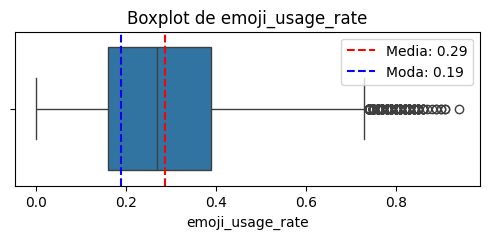


🏁 REVISIÓN EDA FINALIZADA


In [22]:
eda(df1)

In [23]:
eda(df2)

📐 VISIÓN GENERAL DEL DATASET
Vista inicial (primeras 5 filas):


,Name,Review,Rating,#ThumbsUp,Date&Time,App
0,linah sibanda,On this app i cant find a partner,5,0,18-02-2022 01:19,Tinder
1,Norman Johnson,Tinder would be so much better if we could spe...,3,0,18-02-2022 01:16,Tinder
2,David Hume,Still doesn't correctly notify matches or mess...,1,0,18-02-2022 01:11,Tinder
3,Last 1 Standing,"Got banned because I updated my bio to say ""I ...",2,0,18-02-2022 01:11,Tinder
4,Arthur Magamedov,Love it!,5,0,18-02-2022 01:06,Tinder


Dimensiones: 681994 filas × 6 columnas

Información general (dtypes, nulos, memoria):
<class 'pandas.core.frame.DataFrame'>
Index: 681994 entries, 0 to 52993
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Name       681987 non-null  object
 1   Review     680609 non-null  object
 2   Rating     681994 non-null  int64 
 3   #ThumbsUp  681994 non-null  int64 
 4   Date&Time  681994 non-null  object
 5   App        681994 non-null  object
dtypes: int64(2), object(4)
memory usage: 36.4+ MB

🚩 FLAG: duplicados - Filas duplicadas: 0 (0.00%)
----------------------------------------------------------------------
🚑 CALIDAD DE COLUMNAS


,Tipo,Nulos,% Nulos,Valores Únicos,% Cardinalidad
Review,object,1385,0.2,518393,76.01
Name,object,7,0.0,554761,81.34
Rating,int64,0,0.0,6,0.00
#ThumbsUp,int64,0,0.0,683,0.10
Date&Time,object,0,0.0,619021,90.77
App,object,0,0.0,3,0.00



🚩 FLAG: nulos - Clasificación por umbral (% nulos)
  🟢 Bajo (≤ 5%):
    - Review (0.20%)
  🟡 Moderado (5%–20%):
    - Ninguna
  🔴 Alto (> 20%):
    - Ninguna

🔤 NULOS EN VARIABLES CATEGÓRICAS

📌 Name — 🚩 FLAG: nulos_categorica (0.00%)


...


📌 Date&Time — 619021 valores únicos (mostrando hasta 10)


,Valor (muestra)
0,18-02-2022 01:19
1,18-02-2022 01:16
2,18-02-2022 01:11
3,18-02-2022 01:06
4,18-02-2022 00:57
5,18-02-2022 00:52
6,18-02-2022 00:37
7,18-02-2022 00:28
8,18-02-2022 00:23
9,18-02-2022 00:17



📌 App — 3 valores únicos (mostrando hasta 10)


,Valor (muestra)
0,Tinder
1,Bumble
2,Hinge



⚠️ OUTLIERS — Método IQR (1.5x)

🏁 REVISIÓN EDA FINALIZADA
